In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('data/metrics.json') as f:
    metrics = json.load(f)

print(f"Total episodes: {len(metrics)}")
print(f"Keys: {list(metrics[0].keys())}")

Total episodes: 10000
Keys: ['reward_h', 'reward_w', 'mean_happiness', 'mean_stability', 'final_happiness', 'final_stability', 'reflections', 'episode', 'loss_h_policy', 'loss_h_value', 'loss_w_policy', 'loss_w_value']


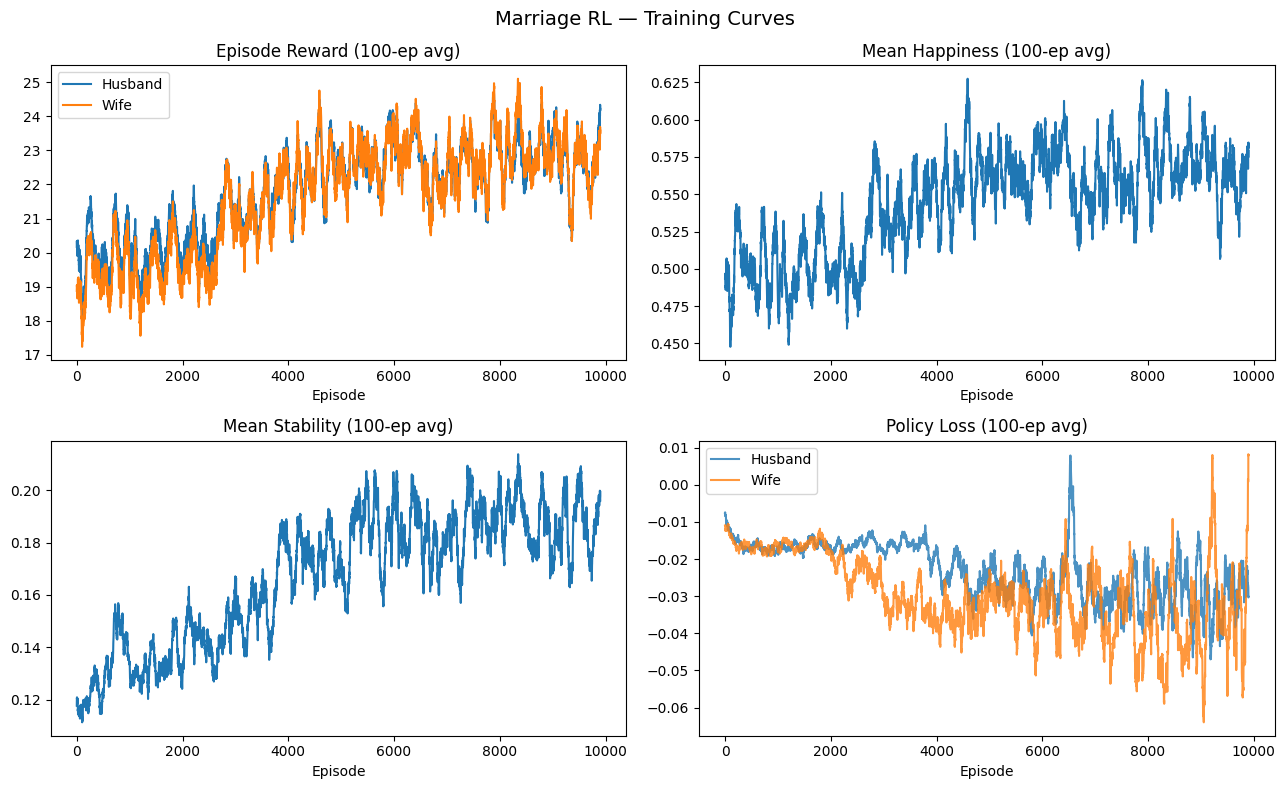

In [2]:
def smooth(vals, w=100):
    if len(vals) < w:
        return vals
    kernel = np.ones(w) / w
    return np.convolve(vals, kernel, mode='valid').tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Marriage RL — Training Curves', fontsize=14)

axes[0, 0].plot(smooth([m['reward_h'] for m in metrics]), label='Husband')
axes[0, 0].plot(smooth([m['reward_w'] for m in metrics]), label='Wife')
axes[0, 0].set_title('Episode Reward (100-ep avg)')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].legend()

axes[0, 1].plot(smooth([m['mean_happiness'] for m in metrics]))
axes[0, 1].set_title('Mean Happiness (100-ep avg)')
axes[0, 1].set_xlabel('Episode')

axes[1, 0].plot(smooth([m['mean_stability'] for m in metrics]))
axes[1, 0].set_title('Mean Stability (100-ep avg)')
axes[1, 0].set_xlabel('Episode')

axes[1, 1].plot(smooth([m['loss_h_policy'] for m in metrics]), label='Husband', alpha=0.8)
axes[1, 1].plot(smooth([m['loss_w_policy'] for m in metrics]), label='Wife', alpha=0.8)
axes[1, 1].set_title('Policy Loss (100-ep avg)')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [3]:
# Final episode stats
last = metrics[-1]
print(f"Episode:          {last['episode']}")
print(f"Reward H/W:       {last['reward_h']:.3f} / {last['reward_w']:.3f}")
print(f"Mean happiness:   {last['mean_happiness']:.3f}")
print(f"Mean stability:   {last['mean_stability']:.3f}")
print(f"Final happiness:  {last['final_happiness']:.3f}")
print(f"Final stability:  {last['final_stability']:.3f}")
print(f"Reflections:      {last['reflections']}")

Episode:          9999
Reward H/W:       20.148 / 21.201
Mean happiness:   0.592
Mean stability:   0.076
Final happiness:  0.737
Final stability:  0.000
Reflections:      30


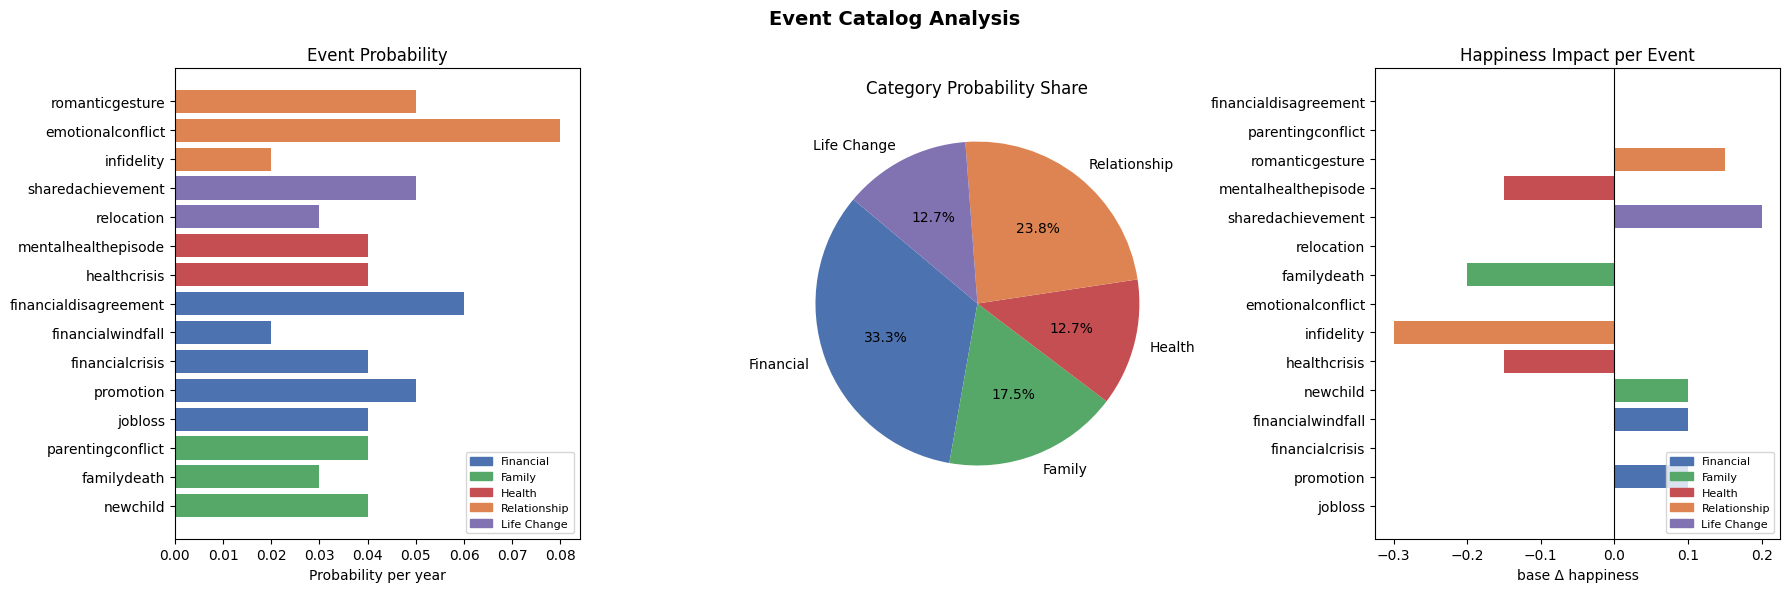

In [4]:
import yaml
from matplotlib.patches import Patch

CATEGORIES = {
    "Financial":    ["job_loss", "promotion", "financial_crisis", "financial_windfall", "financial_disagreement"],
    "Family":       ["new_child", "parenting_conflict", "family_death"],
    "Health":       ["health_crisis", "mental_health_episode"],
    "Relationship": ["infidelity", "emotional_conflict", "romantic_gesture"],
    "Life Change":  ["relocation", "shared_achievement"],
}
EVENT_TO_CAT = {e: cat for cat, evs in CATEGORIES.items() for e in evs}
CAT_COLORS = {
    "Financial":    "#4C72B0",
    "Family":       "#55A868",
    "Health":       "#C44E52",
    "Relationship": "#DD8452",
    "Life Change":  "#8172B2",
}

with open("config/events.yaml") as f:
    events = yaml.safe_load(f)["events"]

names  = [e["name"] for e in events]
probs  = [e["probability"] for e in events]
happy  = [e["base_delta_y"].get("happiness", 0.0) for e in events]
colors = [CAT_COLORS[EVENT_TO_CAT[n]] for n in names]
labels = [n.replace("_", "") for n in names]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Event Catalog Analysis", fontsize=14, fontweight="bold")

# Plot 1: Occurrence probability per event
ax = axes[0]
events_sorted = sorted(range(len(names)), key=lambda i: EVENT_TO_CAT[names[i]])
ax.barh([labels[i] for i in events_sorted], [probs[i] for i in events_sorted],
        color=[colors[i] for i in events_sorted])
ax.set_xlabel("Probability per year")
ax.set_title("Event Probability")
ax.legend(handles=[Patch(color=v, label=k) for k, v in CAT_COLORS.items()], loc="lower right", fontsize=8)

# Plot 2: Category probability pie
ax = axes[1]
cat_probs = {c: 0.0 for c in CATEGORIES}
for name, p in zip(names, probs):
    cat_probs[EVENT_TO_CAT[name]] += p
ax.pie(
    [cat_probs[c] for c in CATEGORIES],
    labels=list(CATEGORIES.keys()),
    colors=[CAT_COLORS[c] for c in CATEGORIES],
    autopct="%1.1f%%",
    startangle=140,
)
ax.set_title("Category Probability Share")

# Plot 3: Base happiness impact per event
ax = axes[2]
ax.barh(labels, happy, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("base Δ happiness")
ax.set_title("Happiness Impact per Event")
ax.legend(handles=[Patch(color=v, label=k) for k, v in CAT_COLORS.items()], loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()


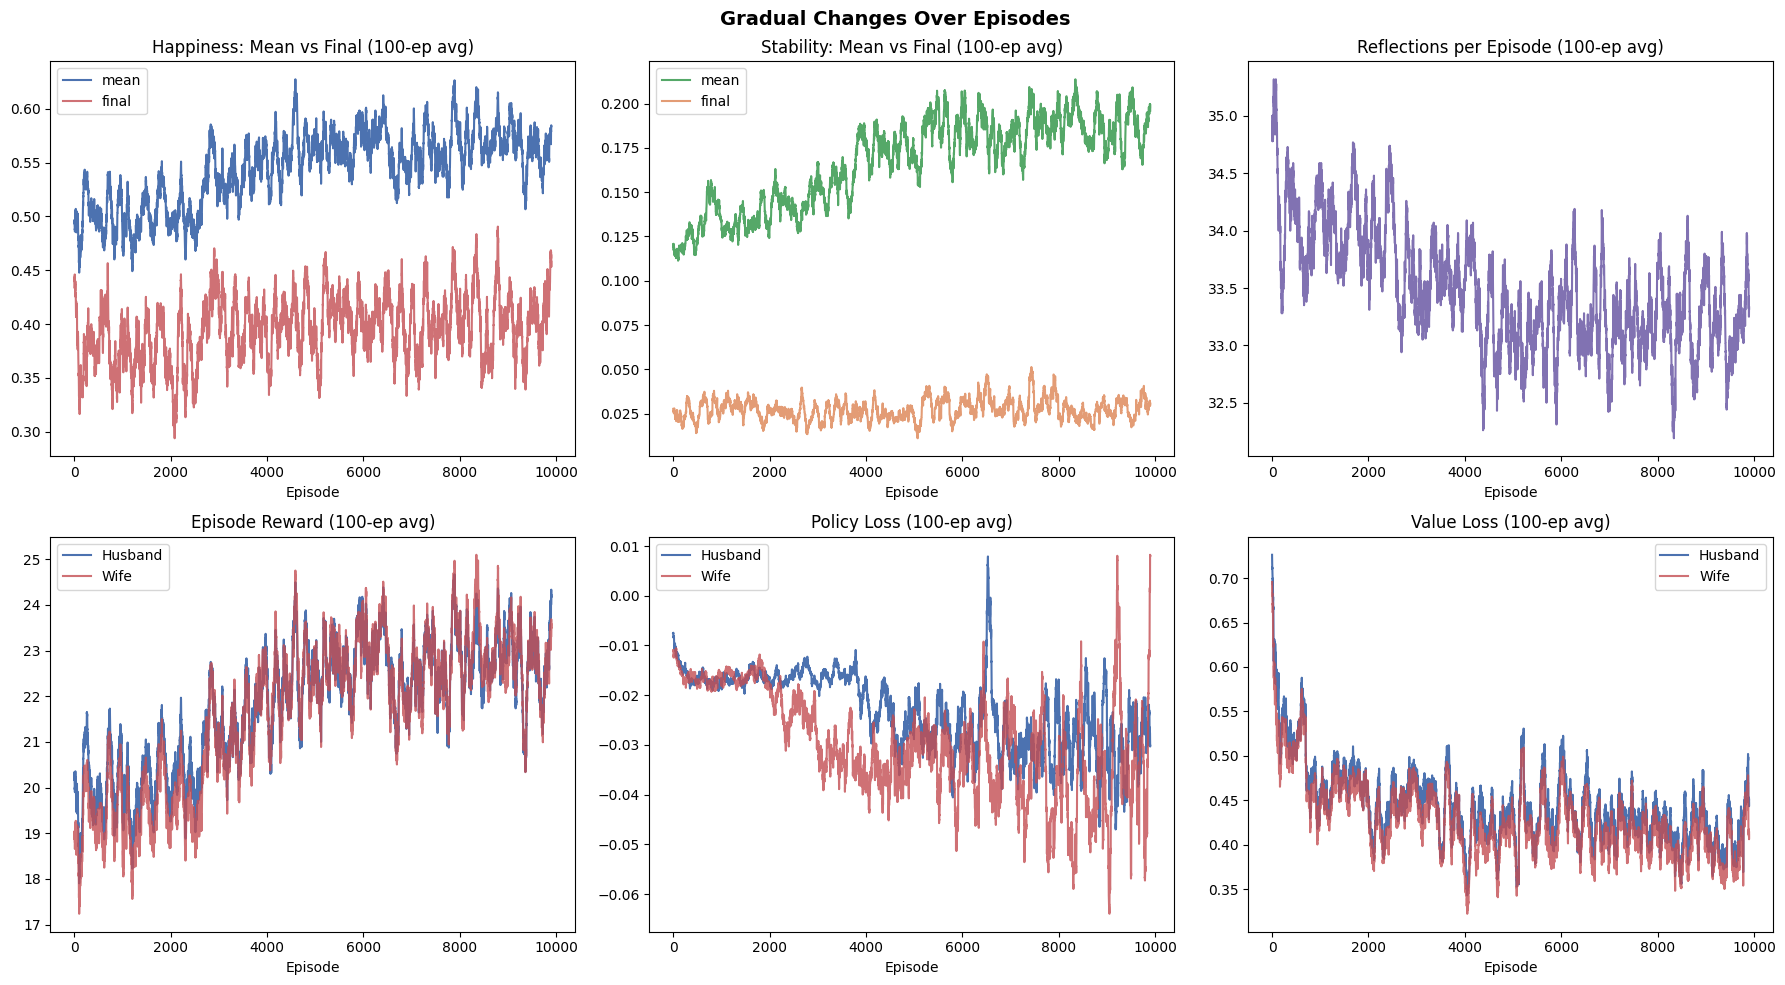

In [5]:
# Gradual changes over episodes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Gradual Changes Over Episodes", fontsize=14, fontweight="bold")

def smooth(vals, w=100):
    if len(vals) < w:
        return vals
    return np.convolve(vals, np.ones(w)/w, mode="valid").tolist()

# Row 0: happiness & stability (mean vs final)
axes[0,0].plot(smooth([m["mean_happiness"] for m in metrics]), label="mean", color="#4C72B0")
axes[0,0].plot(smooth([m["final_happiness"] for m in metrics]), label="final", color="#C44E52", alpha=0.8)
axes[0,0].set_title("Happiness: Mean vs Final (100-ep avg)")
axes[0,0].set_xlabel("Episode"); axes[0,0].legend()

axes[0,1].plot(smooth([m["mean_stability"] for m in metrics]), label="mean", color="#55A868")
axes[0,1].plot(smooth([m["final_stability"] for m in metrics]), label="final", color="#DD8452", alpha=0.8)
axes[0,1].set_title("Stability: Mean vs Final (100-ep avg)")
axes[0,1].set_xlabel("Episode"); axes[0,1].legend()

axes[0,2].plot(smooth([m["reflections"] for m in metrics]), color="#8172B2")
axes[0,2].set_title("Reflections per Episode (100-ep avg)")
axes[0,2].set_xlabel("Episode")

# Row 1: rewards & losses
axes[1,0].plot(smooth([m["reward_h"] for m in metrics]), label="Husband", color="#4C72B0")
axes[1,0].plot(smooth([m["reward_w"] for m in metrics]), label="Wife",    color="#C44E52", alpha=0.8)
axes[1,0].set_title("Episode Reward (100-ep avg)")
axes[1,0].set_xlabel("Episode"); axes[1,0].legend()

axes[1,1].plot(smooth([m["loss_h_policy"] for m in metrics]), label="Husband", color="#4C72B0")
axes[1,1].plot(smooth([m["loss_w_policy"] for m in metrics]), label="Wife",    color="#C44E52", alpha=0.8)
axes[1,1].set_title("Policy Loss (100-ep avg)")
axes[1,1].set_xlabel("Episode"); axes[1,1].legend()

axes[1,2].plot(smooth([m["loss_h_value"] for m in metrics]), label="Husband", color="#4C72B0")
axes[1,2].plot(smooth([m["loss_w_value"] for m in metrics]), label="Wife",    color="#C44E52", alpha=0.8)
axes[1,2].set_title("Value Loss (100-ep avg)")
axes[1,2].set_xlabel("Episode"); axes[1,2].legend()

plt.tight_layout()
plt.show()


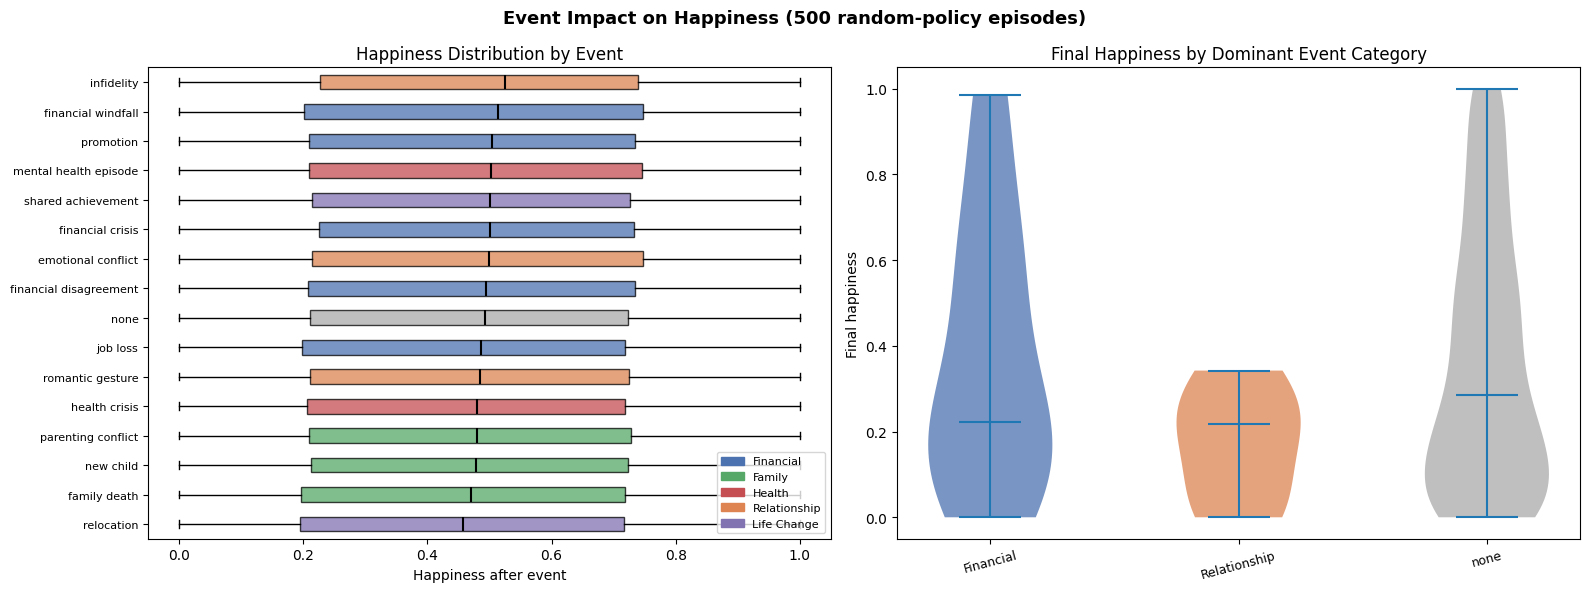

In [6]:
import sys, yaml
sys.path.insert(0, ".")
from collections import defaultdict
from matplotlib.patches import Patch
from src.env.marriage_env import MarriageEnv

CATEGORIES = {
    "Financial":    ["job_loss", "promotion", "financial_crisis", "financial_windfall", "financial_disagreement"],
    "Family":       ["new_child", "parenting_conflict", "family_death"],
    "Health":       ["health_crisis", "mental_health_episode"],
    "Relationship": ["infidelity", "emotional_conflict", "romantic_gesture"],
    "Life Change":  ["relocation", "shared_achievement"],
}
EVENT_TO_CAT = {e: cat for cat, evs in CATEGORIES.items() for e in evs}
CAT_COLORS = {
    "Financial":    "#4C72B0",
    "Family":       "#55A868",
    "Health":       "#C44E52",
    "Relationship": "#DD8452",
    "Life Change":  "#8172B2",
    "none":         "#AAAAAA",
}

# Run episodes with random policy, track per-step (event, happiness, stability)
N_EPISODES = 500
env = MarriageEnv("config/default.yaml", "config/events.yaml")

# happiness after each event type
event_happiness = defaultdict(list)
# per-episode final happiness grouped by dominant event category
cat_final_happiness = defaultdict(list)

for ep in range(N_EPISODES):
    obs, info_r = env.reset()
    done = False
    ep_cat_counts = defaultdict(int)
    while not done:
        action = env.action_space.sample()
        obs, reward, done, _, info = env.step(action)
        ev = info["event"]
        cat = EVENT_TO_CAT.get(ev, "none")
        event_happiness[ev].append(info["happiness"])
        ep_cat_counts[cat] += 1
    dominant_cat = max(ep_cat_counts, key=ep_cat_counts.get) if ep_cat_counts else "none"
    cat_final_happiness[dominant_cat].append(info["happiness"])

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Event Impact on Happiness (500 random-policy episodes)", fontsize=13, fontweight="bold")

# Plot 1: box plot — happiness distribution after each event
ax = axes[0]
ev_names = sorted(event_happiness.keys(), key=lambda e: np.median(event_happiness[e]))
data  = [event_happiness[e] for e in ev_names]
bcolors = [CAT_COLORS[EVENT_TO_CAT.get(e, "none")] for e in ev_names]
bp = ax.boxplot(data, vert=False, patch_artist=True,
                medianprops=dict(color="black", linewidth=1.5))
for patch, color in zip(bp["boxes"], bcolors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_yticks(range(1, len(ev_names)+1))
ax.set_yticklabels([e.replace("_", " ") for e in ev_names], fontsize=8)
ax.set_xlabel("Happiness after event")
ax.set_title("Happiness Distribution by Event")
ax.legend(handles=[Patch(color=v, label=k) for k, v in CAT_COLORS.items() if k != "none"],
          fontsize=8, loc="lower right")

# Plot 2: violin — final episode happiness by dominant event category
ax = axes[1]
cats = [c for c in list(CATEGORIES.keys()) + ["none"] if c in cat_final_happiness]
vdata = [cat_final_happiness[c] for c in cats]
vp = ax.violinplot(vdata, vert=True, showmedians=True)
for body, cat in zip(vp["bodies"], cats):
    body.set_facecolor(CAT_COLORS[cat])
    body.set_alpha(0.75)
ax.set_xticks(range(1, len(cats)+1))
ax.set_xticklabels(cats, fontsize=9, rotation=15)
ax.set_ylabel("Final happiness")
ax.set_title("Final Happiness by Dominant Event Category")

plt.tight_layout()
plt.show()


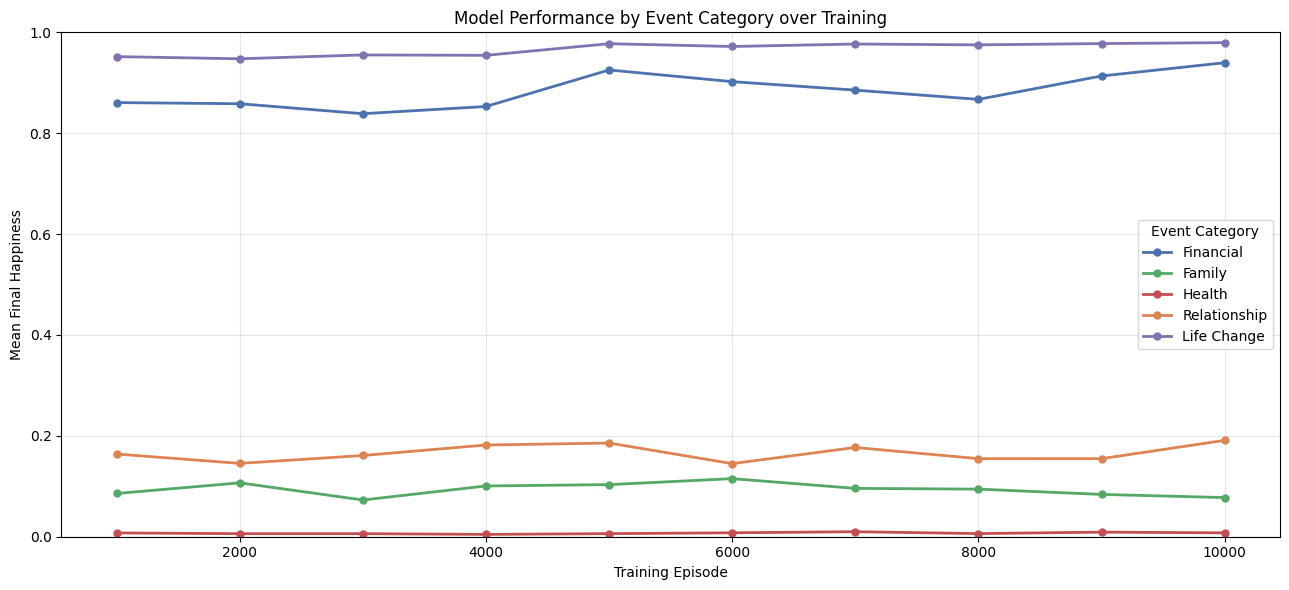

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("data/eval_history.json") as f:
    eval_history = json.load(f)

CATEGORIES = ["Financial", "Family", "Health", "Relationship", "Life Change"]
CAT_COLORS = {
    "Financial":    "#4C72B0",
    "Family":       "#55A868",
    "Health":       "#C44E52",
    "Relationship": "#DD8452",
    "Life Change":  "#8172B2",
}

episodes = [e["episode"] for e in eval_history]

fig, ax = plt.subplots(figsize=(13, 6))
for cat in CATEGORIES:
    scores = [e[cat] for e in eval_history]
    ax.plot(episodes, scores, marker="o", label=cat,
            color=CAT_COLORS[cat], linewidth=2, markersize=5)

ax.set_xlabel("Training Episode")
ax.set_ylabel("Mean Final Happiness")
ax.set_title("Model Performance by Event Category over Training")
ax.legend(title="Event Category")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/var/folders/1f/d36l_3312r7ddvq29jp_r4mc0000gn/T/ipykernel_21792/174896699.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues", n_eps + 2)


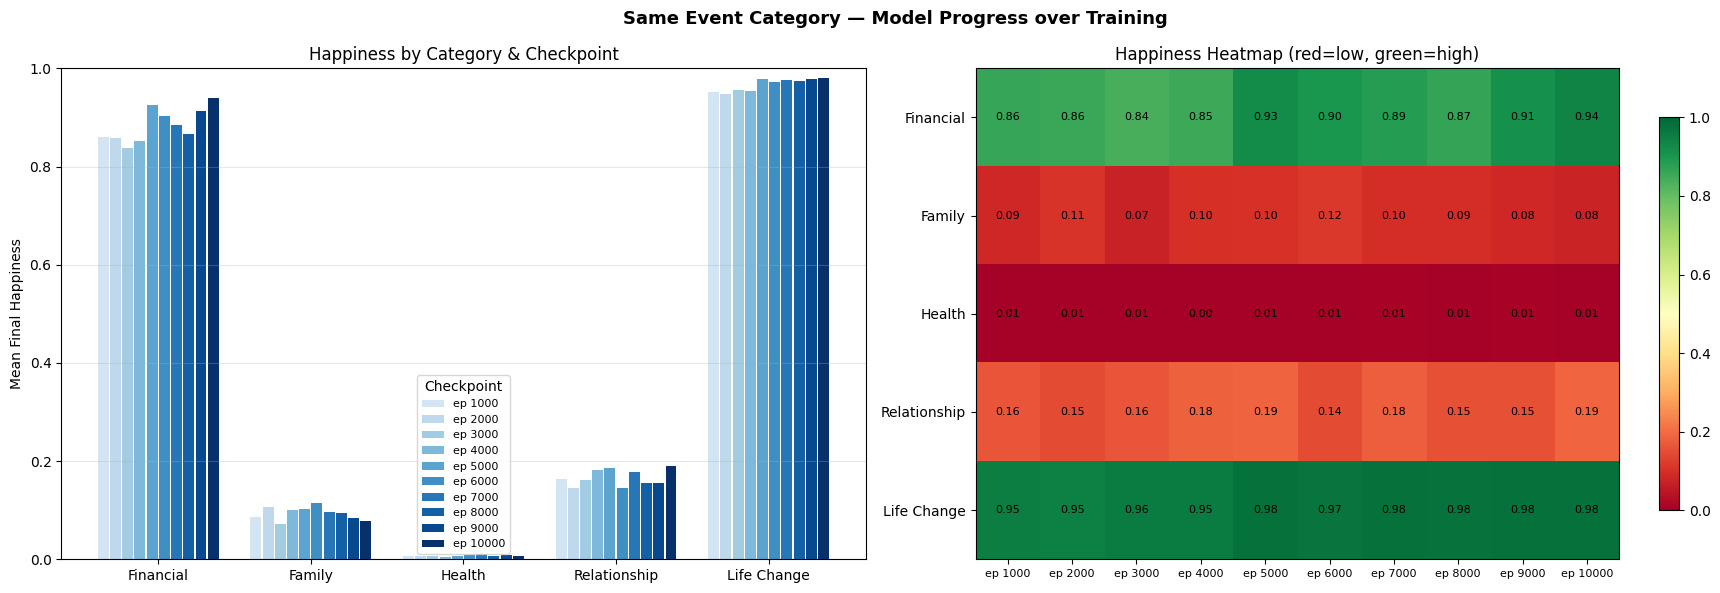

In [8]:
# Vertical comparison: same event category, different training stages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

CATEGORIES = ["Financial", "Family", "Health", "Relationship", "Life Change"]
episodes = [e["episode"] for e in eval_history]
n_eps = len(episodes)
n_cats = len(CATEGORIES)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Same Event Category — Model Progress over Training", fontsize=13, fontweight="bold")

# ── Left: grouped bar chart (x=category, groups=checkpoints) ─────────────
ax = axes[0]
cmap = cm.get_cmap("Blues", n_eps + 2)
bar_colors = [cmap(i + 2) for i in range(n_eps)]
x = np.arange(n_cats)
width = 0.8 / n_eps
for i, (ep, color) in enumerate(zip(episodes, bar_colors)):
    scores = [eval_history[i][cat] for cat in CATEGORIES]
    offset = (i - n_eps / 2 + 0.5) * width
    ax.bar(x + offset, scores, width=width * 0.9, color=color, label=f"ep {ep}")
ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES, fontsize=10)
ax.set_ylabel("Mean Final Happiness")
ax.set_title("Happiness by Category & Checkpoint")
ax.set_ylim(0, 1)
ax.legend(title="Checkpoint", fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── Right: heatmap (x=checkpoint, y=category) ────────────────────────────
ax = axes[1]
data = np.array([[e[cat] for e in eval_history] for cat in CATEGORIES])
im = ax.imshow(data, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(n_eps))
ax.set_xticklabels([f"ep {ep}" for ep in episodes], fontsize=8)
ax.set_yticks(range(n_cats))
ax.set_yticklabels(CATEGORIES, fontsize=10)
ax.set_title("Happiness Heatmap (red=low, green=high)")
for i in range(n_cats):
    for j in range(n_eps):
        ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center",
                fontsize=8, color="black")
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()
